In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns',None)

In [3]:
flights = pd.read_csv('flights_sampled.csv',na_values=['-'])
flights.shape

C:\Users\royal\AppData\Local\Temp\ipykernel_3480\1283145424.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv('flights_sampled.csv',na_values=['-'])


(5819079, 31)

In [4]:
flights.head(10)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,20.0,-5.0,18.0,38.0,217.0,230.0,206.0,1589,604.0,6.0,602,610.0,8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,19.0,-6.0,11.0,30.0,181.0,170.0,154.0,1299,504.0,5.0,526,509.0,-17.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,44.0,14.0,13.0,57.0,273.0,249.0,228.0,2125,745.0,8.0,803,753.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,19.0,-11.0,17.0,36.0,195.0,193.0,173.0,1464,529.0,3.0,545,532.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,33.0,3.0,12.0,45.0,221.0,203.0,186.0,1747,651.0,5.0,711,656.0,-15.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
flights.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [6]:
flights = flights[['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME','DEPARTURE_DELAY','SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY','CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']]

In [7]:
flights.head(10)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,ANC,SEA,5,2354.0,-11.0,430,408.0,-22.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,LAX,PBI,10,2.0,-8.0,750,741.0,-9.0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,SFO,CLT,20,18.0,-2.0,806,811.0,5.0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,LAX,MIA,20,15.0,-5.0,805,756.0,-9.0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,SEA,ANC,25,24.0,-1.0,320,259.0,-21.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,2015,1,1,4,DL,SFO,MSP,25,20.0,-5.0,602,610.0,8.0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,2015,1,1,4,NK,LAS,MSP,25,19.0,-6.0,526,509.0,-17.0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,2015,1,1,4,US,LAX,CLT,30,44.0,14.0,803,753.0,-10.0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,2015,1,1,4,AA,SFO,DFW,30,19.0,-11.0,545,532.0,-13.0,0,NaN,NaN,NaN,NaN,NaN,NaN
9,2015,1,1,4,DL,LAS,ATL,30,33.0,3.0,711,656.0,-15.0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
flights.isna().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [9]:
flights[flights['ARRIVAL_DELAY'].isna()].shape

(105071, 20)

In [10]:
flights[flights['ARRIVAL_DELAY'].isna()]

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
32,2015,1,1,4,AS,ANC,SEA,135,NaN,NaN,600,NaN,NaN,1,A,NaN,NaN,NaN,NaN,NaN
42,2015,1,1,4,AA,PHX,DFW,200,NaN,NaN,500,NaN,NaN,1,B,NaN,NaN,NaN,NaN,NaN
68,2015,1,1,4,OO,MAF,IAH,510,NaN,NaN,637,NaN,NaN,1,B,NaN,NaN,NaN,NaN,NaN
82,2015,1,1,4,MQ,SGF,DFW,525,NaN,NaN,700,NaN,NaN,1,B,NaN,NaN,NaN,NaN,NaN
90,2015,1,1,4,OO,RDD,SFO,530,NaN,NaN,700,NaN,NaN,1,A,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5818157,2015,12,31,4,UA,SFO,LAX,2000,NaN,NaN,2136,NaN,NaN,1,A,NaN,NaN,NaN,NaN,NaN
5818160,2015,12,31,4,WN,MDW,ABQ,2000,2013.0,13.0,2215,2325.0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
5818318,2015,12,31,4,AA,MIA,SAN,2019,NaN,NaN,2256,NaN,NaN,1,A,NaN,NaN,NaN,NaN,NaN
5818777,2015,12,31,4,NK,FLL,IAG,2155,NaN,NaN,50,NaN,NaN,1,A,NaN,NaN,NaN,NaN,NaN


In [11]:
na_values=flights[flights['AIR_SYSTEM_DELAY'].isna() & flights['SECURITY_DELAY'].isna() & flights['AIRLINE_DELAY'].isna() & flights['LATE_AIRCRAFT_DELAY'].isna() & flights['WEATHER_DELAY'].isna()] 
na_values.shape

(4755640, 20)

array([[<Axes: title={'center': 'YEAR'}>,
        <Axes: title={'center': 'MONTH'}>,
        <Axes: title={'center': 'DAY'}>,
        <Axes: title={'center': 'DAY_OF_WEEK'}>],
       [<Axes: title={'center': 'SCHEDULED_DEPARTURE'}>,
        <Axes: title={'center': 'DEPARTURE_TIME'}>,
        <Axes: title={'center': 'DEPARTURE_DELAY'}>,
        <Axes: title={'center': 'SCHEDULED_ARRIVAL'}>],
       [<Axes: title={'center': 'ARRIVAL_TIME'}>,
        <Axes: title={'center': 'ARRIVAL_DELAY'}>,
        <Axes: title={'center': 'CANCELLED'}>,
        <Axes: title={'center': 'AIR_SYSTEM_DELAY'}>],
       [<Axes: title={'center': 'SECURITY_DELAY'}>,
        <Axes: title={'center': 'AIRLINE_DELAY'}>,
        <Axes: title={'center': 'LATE_AIRCRAFT_DELAY'}>,
        <Axes: title={'center': 'WEATHER_DELAY'}>]], dtype=object)

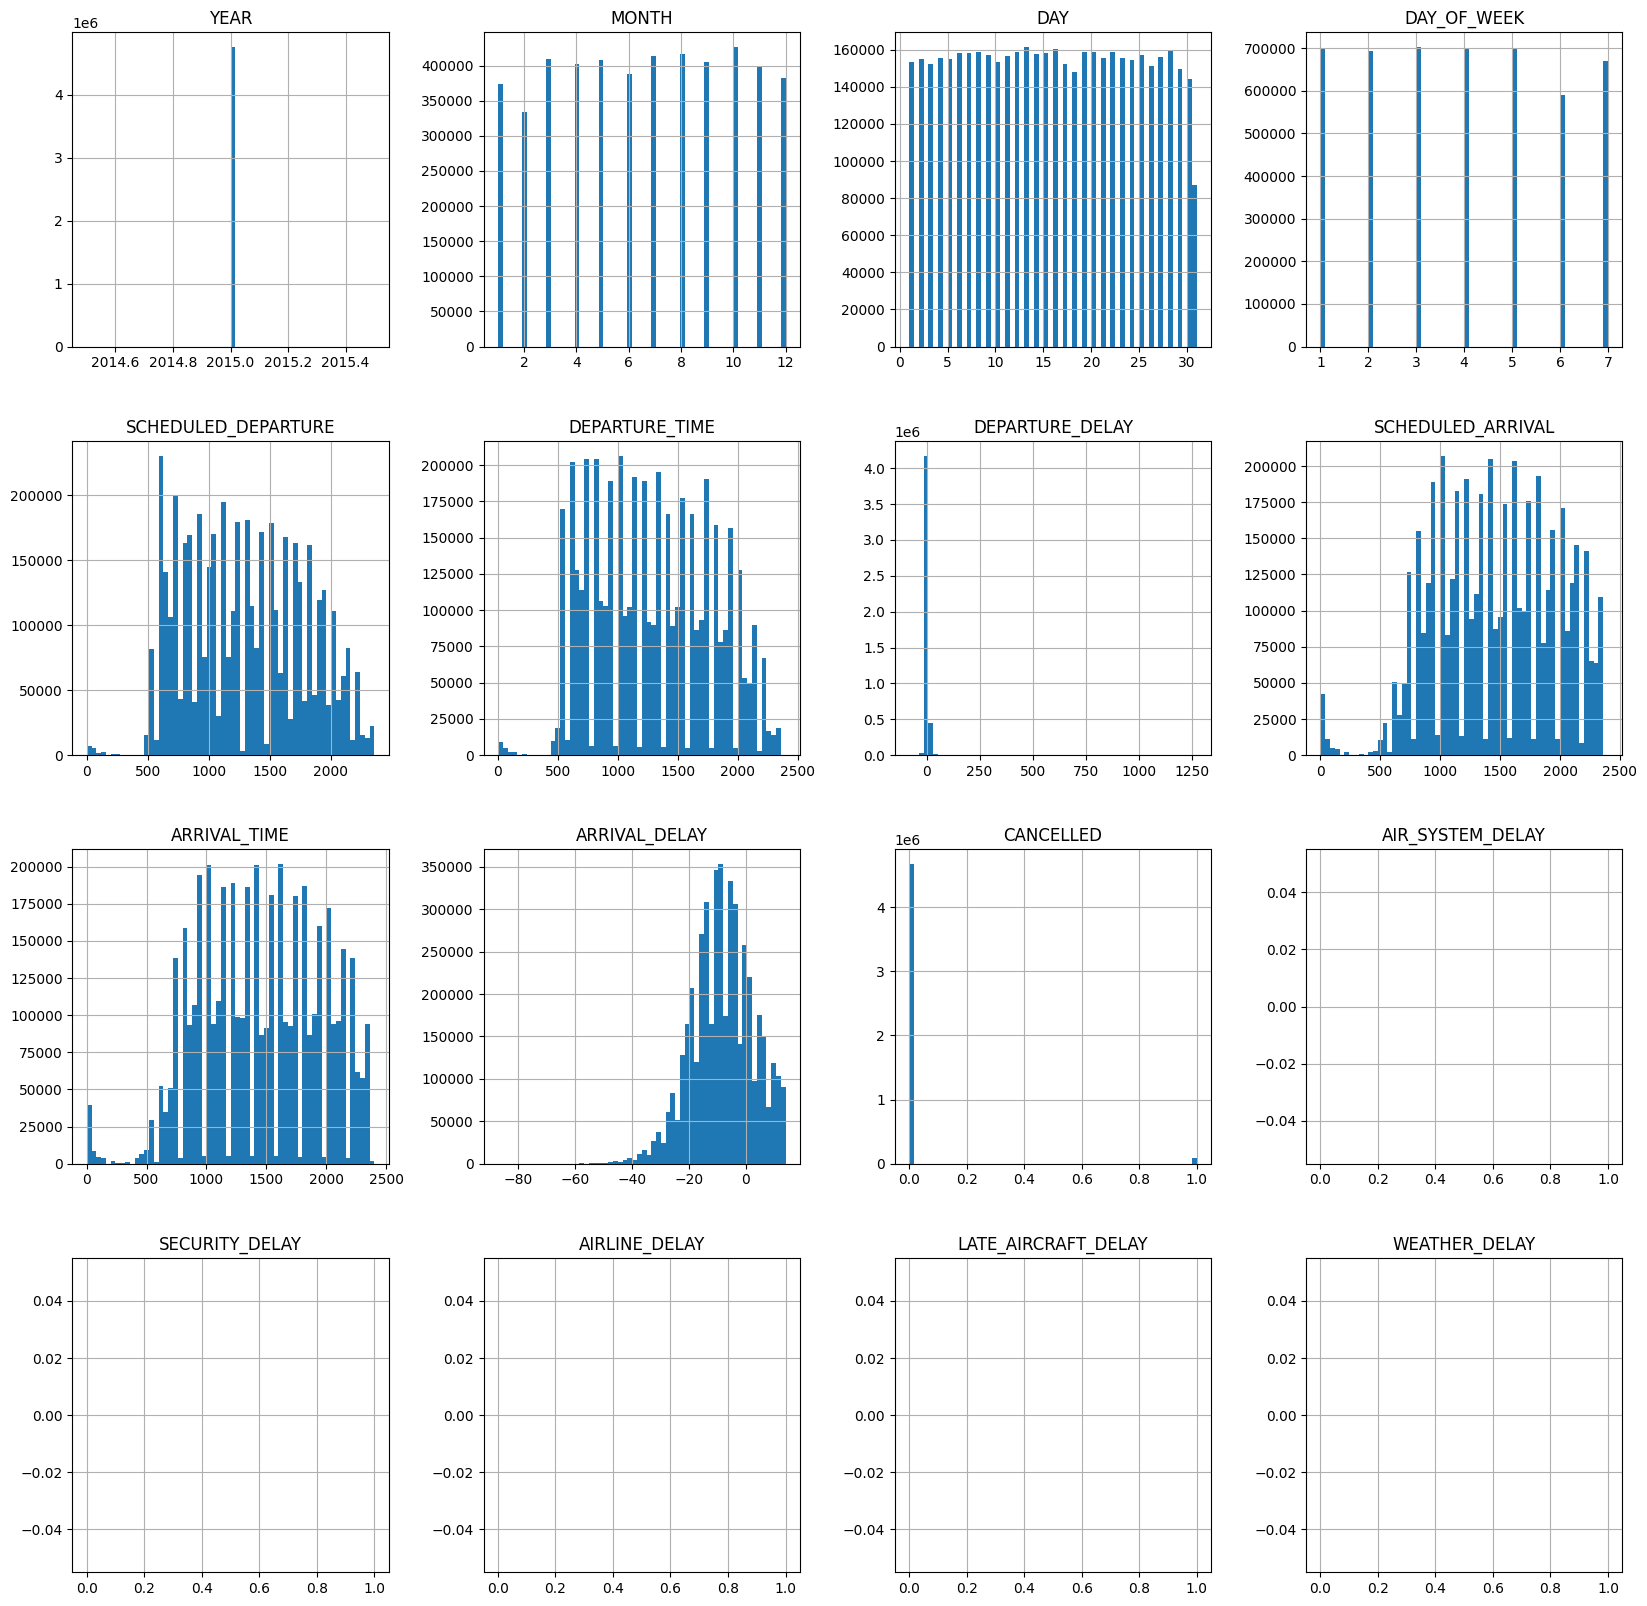

In [12]:
na_values.hist(bins=60,figsize=(20,20))

In [13]:
na_values[na_values['ARRIVAL_DELAY']>13]

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
94,2015,1,1,4,UA,IAD,IAH,535,541.0,6.0,802,816.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
109,2015,1,1,4,EV,ATL,IAD,540,556.0,16.0,725,739.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
181,2015,1,1,4,UA,RNO,DEN,600,557.0,-3.0,910,924.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
204,2015,1,1,4,AA,MIA,PHL,600,604.0,4.0,844,858.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
490,2015,1,1,4,F9,SLC,DEN,615,617.0,2.0,747,801.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5817972,2015,12,31,4,DL,DTW,LGA,1940,2009.0,29.0,2126,2140.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5818194,2015,12,31,4,NK,FLL,DTW,2005,2029.0,24.0,2305,2319.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5818308,2015,12,31,4,B6,LGB,OAK,2015,2033.0,18.0,2132,2146.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5818644,2015,12,31,4,B6,PDX,JFK,2120,2114.0,-6.0,518,532.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
arrival_na = flights[flights['ARRIVAL_DELAY'].isna()]
arrival_na

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
32,2015,1,1,4,AS,ANC,SEA,135,NaN,NaN,600,NaN,NaN,1,A,NaN,NaN,NaN,NaN,NaN
42,2015,1,1,4,AA,PHX,DFW,200,NaN,NaN,500,NaN,NaN,1,B,NaN,NaN,NaN,NaN,NaN
68,2015,1,1,4,OO,MAF,IAH,510,NaN,NaN,637,NaN,NaN,1,B,NaN,NaN,NaN,NaN,NaN
82,2015,1,1,4,MQ,SGF,DFW,525,NaN,NaN,700,NaN,NaN,1,B,NaN,NaN,NaN,NaN,NaN
90,2015,1,1,4,OO,RDD,SFO,530,NaN,NaN,700,NaN,NaN,1,A,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5818157,2015,12,31,4,UA,SFO,LAX,2000,NaN,NaN,2136,NaN,NaN,1,A,NaN,NaN,NaN,NaN,NaN
5818160,2015,12,31,4,WN,MDW,ABQ,2000,2013.0,13.0,2215,2325.0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
5818318,2015,12,31,4,AA,MIA,SAN,2019,NaN,NaN,2256,NaN,NaN,1,A,NaN,NaN,NaN,NaN,NaN
5818777,2015,12,31,4,NK,FLL,IAG,2155,NaN,NaN,50,NaN,NaN,1,A,NaN,NaN,NaN,NaN,NaN


In [15]:
arrival_na['CANCELLED'].value_counts()

CANCELLED
1    89884
0    15187
Name: count, dtype: int64

In [16]:
flights = flights[~flights['ARRIVAL_DELAY'].isna()]
flights.shape

(5714008, 20)

In [17]:
flights.isna().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME               0
DEPARTURE_DELAY              0
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME                 0
ARRIVAL_DELAY                0
CANCELLED                    0
CANCELLATION_REASON    5714008
AIR_SYSTEM_DELAY       4650569
SECURITY_DELAY         4650569
AIRLINE_DELAY          4650569
LATE_AIRCRAFT_DELAY    4650569
WEATHER_DELAY          4650569
dtype: int64

In [18]:
flights[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']] = flights[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].fillna(0)
flights

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,ANC,SEA,5,2354.0,-11.0,430,408.0,-22.0,0,NaN,0.0,0.0,0.0,0.0,0.0
1,2015,1,1,4,AA,LAX,PBI,10,2.0,-8.0,750,741.0,-9.0,0,NaN,0.0,0.0,0.0,0.0,0.0
2,2015,1,1,4,US,SFO,CLT,20,18.0,-2.0,806,811.0,5.0,0,NaN,0.0,0.0,0.0,0.0,0.0
3,2015,1,1,4,AA,LAX,MIA,20,15.0,-5.0,805,756.0,-9.0,0,NaN,0.0,0.0,0.0,0.0,0.0
4,2015,1,1,4,AS,SEA,ANC,25,24.0,-1.0,320,259.0,-21.0,0,NaN,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,LAX,BOS,2359,2355.0,-4.0,819,753.0,-26.0,0,NaN,0.0,0.0,0.0,0.0,0.0
5819075,2015,12,31,4,B6,JFK,PSE,2359,2355.0,-4.0,446,430.0,-16.0,0,NaN,0.0,0.0,0.0,0.0,0.0
5819076,2015,12,31,4,B6,JFK,SJU,2359,2350.0,-9.0,440,432.0,-8.0,0,NaN,0.0,0.0,0.0,0.0,0.0
5819077,2015,12,31,4,B6,MCO,SJU,2359,2353.0,-6.0,340,330.0,-10.0,0,NaN,0.0,0.0,0.0,0.0,0.0


array([[<Axes: title={'center': 'YEAR'}>,
        <Axes: title={'center': 'MONTH'}>,
        <Axes: title={'center': 'DAY'}>,
        <Axes: title={'center': 'DAY_OF_WEEK'}>],
       [<Axes: title={'center': 'SCHEDULED_DEPARTURE'}>,
        <Axes: title={'center': 'DEPARTURE_TIME'}>,
        <Axes: title={'center': 'DEPARTURE_DELAY'}>,
        <Axes: title={'center': 'SCHEDULED_ARRIVAL'}>],
       [<Axes: title={'center': 'ARRIVAL_TIME'}>,
        <Axes: title={'center': 'ARRIVAL_DELAY'}>,
        <Axes: title={'center': 'CANCELLED'}>,
        <Axes: title={'center': 'AIR_SYSTEM_DELAY'}>],
       [<Axes: title={'center': 'SECURITY_DELAY'}>,
        <Axes: title={'center': 'AIRLINE_DELAY'}>,
        <Axes: title={'center': 'LATE_AIRCRAFT_DELAY'}>,
        <Axes: title={'center': 'WEATHER_DELAY'}>]], dtype=object)

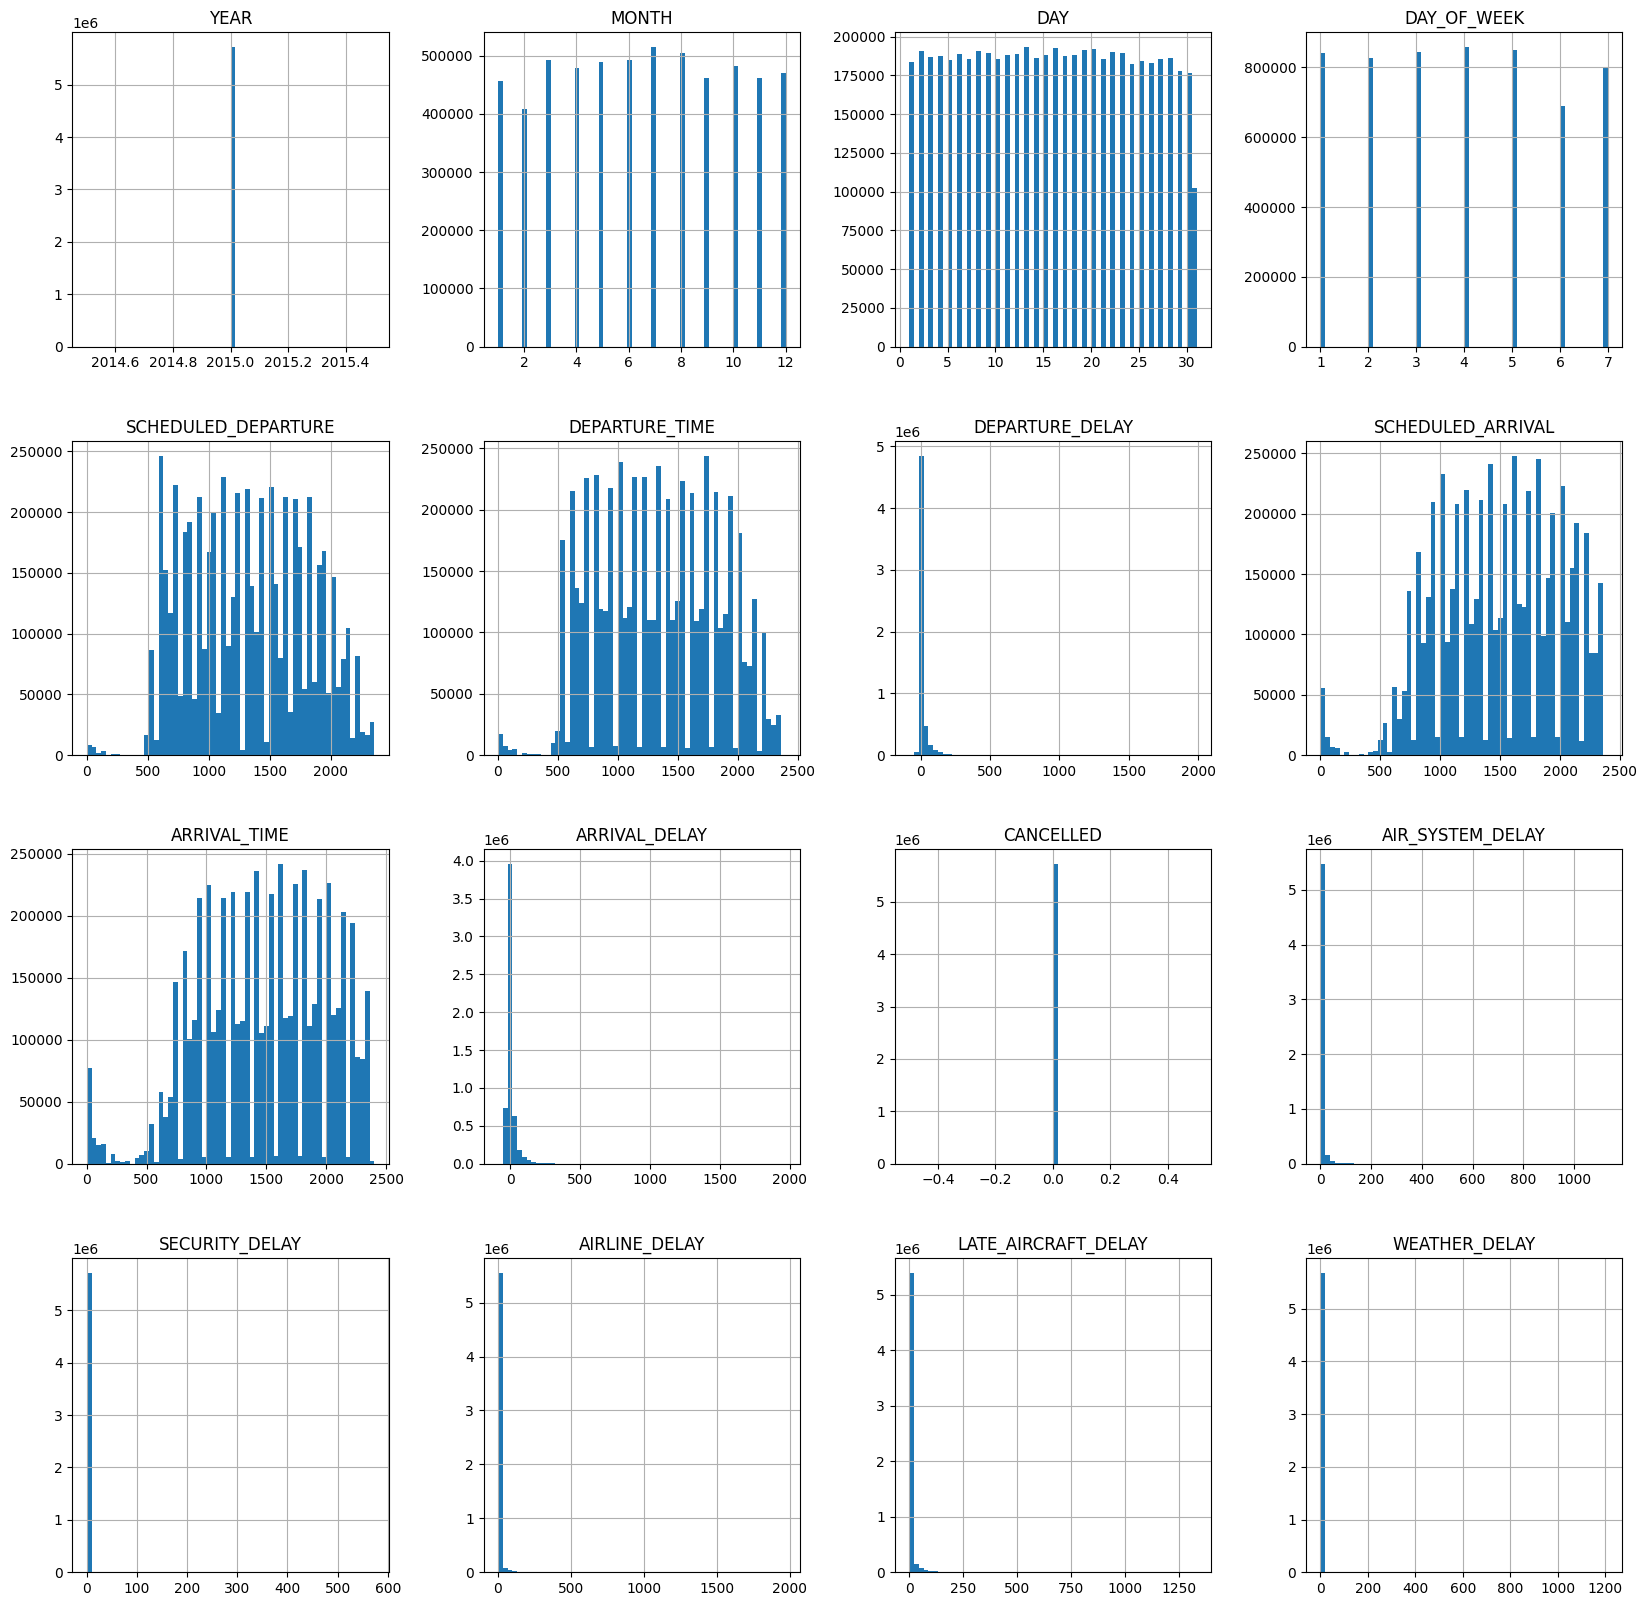

In [19]:
flights.hist(bins=60 , figsize=(20,20))

In [20]:
flights[flights['ARRIVAL_DELAY']>1500]

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
264495,2015,1,18,7,AA,LAS,LAX,1130,1414.0,1604.0,1246,1519.0,1593.0,0,NaN,0.0,0.0,1593.0,0.0,0.0
337720,2015,1,23,5,AA,BHM,DFW,700,1608.0,1988.0,914,1805.0,1971.0,0,NaN,0.0,0.0,1971.0,0.0,0.0
396544,2015,1,27,2,AA,FAT,DFW,659,850.0,1551.0,1210,1356.0,1546.0,0,NaN,0.0,0.0,1546.0,0.0,0.0
886984,2015,2,28,6,AA,STL,MIA,620,847.0,1587.0,1008,1315.0,1627.0,0,NaN,40.0,0.0,1587.0,0.0,0.0
949876,2015,3,4,3,AA,HNL,LAX,828,1057.0,1589.0,1555,1811.0,1576.0,0,NaN,0.0,0.0,1576.0,0.0,0.0
1047179,2015,3,10,2,AA,SAT,DFW,850,1047.0,1557.0,1000,1154.0,1554.0,0,NaN,0.0,0.0,1554.0,0.0,0.0
1278418,2015,3,24,2,AA,OMA,DFW,1103,1352.0,1609.0,1255,1533.0,1598.0,0,NaN,0.0,0.0,1563.0,35.0,0.0
1290061,2015,3,25,3,AA,SMF,DFW,625,748.0,1523.0,1149,1303.0,1514.0,0,NaN,0.0,0.0,1514.0,0.0,0.0
1841449,2015,4,28,2,AA,SAN,JFK,745,927.0,1542.0,1615,1809.0,1554.0,0,NaN,12.0,0.0,838.0,704.0,0.0
2739880,2015,6,22,1,AA,RIC,DFW,715,837.0,1522.0,920,1028.0,1508.0,0,NaN,0.0,0.0,1508.0,0.0,0.0


In [21]:
flights.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [22]:
# pd.to_numeric(flights['WEATHER_DELAY'])

In [23]:
#flights.iloc(107)

In [24]:
flights.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
       'DEPARTURE_DELAY', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY',
       'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY'],
      dtype='object')

In [25]:
flights = flights[['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
       'SCHEDULED_DEPARTURE','SCHEDULED_ARRIVAL','ARRIVAL_DELAY',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']]

In [26]:
flights.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
SCHEDULED_DEPARTURE      int64
SCHEDULED_ARRIVAL        int64
ARRIVAL_DELAY          float64
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [27]:
#len(flights['DESTINATION_AIRPORT'].value_counts())

In [28]:
flights['all_delay'] = flights[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].sum(axis=1)
flights

C:\Users\royal\AppData\Local\Temp\ipykernel_3480\3484429573.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flights['all_delay'] = flights[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,all_delay
0,2015,1,1,4,AS,5,430,-22.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015,1,1,4,AA,10,750,-9.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015,1,1,4,US,20,806,5.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015,1,1,4,AA,20,805,-9.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015,1,1,4,AS,25,320,-21.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,2359,819,-26.0,0.0,0.0,0.0,0.0,0.0,0.0
5819075,2015,12,31,4,B6,2359,446,-16.0,0.0,0.0,0.0,0.0,0.0,0.0
5819076,2015,12,31,4,B6,2359,440,-8.0,0.0,0.0,0.0,0.0,0.0,0.0
5819077,2015,12,31,4,B6,2359,340,-10.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
flights[flights['all_delay'] >0 ].shape

(1063439, 14)

In [30]:
flights['delay_reason']=np.where(flights['all_delay'] >0 , flights[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].idxmax(axis=1),'NO_DELAY')

C:\Users\royal\AppData\Local\Temp\ipykernel_3480\338742209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flights['delay_reason']=np.where(flights['all_delay'] >0 , flights[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',


In [31]:
flights

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,all_delay,delay_reason
0,2015,1,1,4,AS,5,430,-22.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
1,2015,1,1,4,AA,10,750,-9.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
2,2015,1,1,4,US,20,806,5.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
3,2015,1,1,4,AA,20,805,-9.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
4,2015,1,1,4,AS,25,320,-21.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,2359,819,-26.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
5819075,2015,12,31,4,B6,2359,446,-16.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
5819076,2015,12,31,4,B6,2359,440,-8.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
5819077,2015,12,31,4,B6,2359,340,-10.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY


In [32]:
flights['delay_reason'].value_counts()

delay_reason
NO_DELAY               4650569
LATE_AIRCRAFT_DELAY     410647
AIRLINE_DELAY           311386
AIR_SYSTEM_DELAY        303784
WEATHER_DELAY            35711
SECURITY_DELAY            1911
Name: count, dtype: int64

<Axes: >

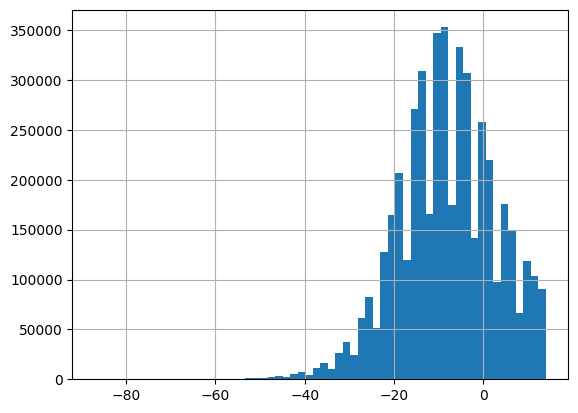

In [33]:
flights[flights['delay_reason']=='NO_DELAY']['ARRIVAL_DELAY'].hist(bins=60)

In [34]:
flights.columns


Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'SCHEDULED_DEPARTURE',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'all_delay', 'delay_reason'],
      dtype='object')

In [35]:
flights = flights[['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'SCHEDULED_DEPARTURE',
       'SCHEDULED_ARRIVAL','delay_reason']]

In [36]:
x_flights = flights[['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'SCHEDULED_DEPARTURE',
       'SCHEDULED_ARRIVAL']]
x_flights=pd.get_dummies(x_flights)

y_flights = flights[['delay_reason']]

In [37]:
x_flights

,YEAR,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,AIRLINE_AA,AIRLINE_AS,AIRLINE_B6,AIRLINE_DL,AIRLINE_EV,AIRLINE_F9,AIRLINE_HA,AIRLINE_MQ,AIRLINE_NK,AIRLINE_OO,AIRLINE_UA,AIRLINE_US,AIRLINE_VX,AIRLINE_WN
0,2015,1,1,4,5,430,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,2015,1,1,4,10,750,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2015,1,1,4,20,806,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,2015,1,1,4,20,805,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2015,1,1,4,25,320,False,True,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,2359,819,False,False,True,False,False,False,False,False,False,False,False,False,False,False
5819075,2015,12,31,4,2359,446,False,False,True,False,False,False,False,False,False,False,False,False,False,False
5819076,2015,12,31,4,2359,440,False,False,True,False,False,False,False,False,False,False,False,False,False,False
5819077,2015,12,31,4,2359,340,False,False,True,False,False,False,False,False,False,False,False,False,False,False


In [38]:
#Splitting into train and test datasets
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x_flights,y_flights,test_size=0.3, random_state=15)

In [39]:
#Splitting into train , test and validation datasets
"""
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x_flights,y_flights,test_size=0.3, random_state=15)
x_train,x_validation,y_train,y_validation = train_test_split(x_train,y_train,test_size=0.3,random_state=15)
"""

'\nfrom sklearn.model_selection import train_test_split \nx_train,x_test,y_train,y_test = train_test_split(x_flights,y_flights,test_size=0.3, random_state=15)\nx_train,x_validation,y_train,y_validation = train_test_split(x_train,y_train,test_size=0.3,random_state=15)\n'

In [40]:
# dealing with imbalanced-learn
#pip list

In [41]:
#pip install imbalanced-learn
# !conda install -c conda-forge imbalanced-learn

In [42]:
y_train.value_counts()

delay_reason       
NO_DELAY               3255216
LATE_AIRCRAFT_DELAY     287400
AIRLINE_DELAY           218072
AIR_SYSTEM_DELAY        212647
WEATHER_DELAY            25128
SECURITY_DELAY            1342
Name: count, dtype: int64

In [43]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=0)
x_resampled,y_resampled = ros.fit_resample(x_train,y_train)

In [44]:
y_resampled.value_counts()

delay_reason       
AIRLINE_DELAY          3255216
AIR_SYSTEM_DELAY       3255216
LATE_AIRCRAFT_DELAY    3255216
NO_DELAY               3255216
SECURITY_DELAY         3255216
WEATHER_DELAY          3255216
Name: count, dtype: int64

In [45]:
# training
from sklearn.tree import DecisionTreeClassifier 

clf = DecisionTreeClassifier().fit(x_train,y_train)

In [46]:
y_pred = clf.predict(x_test)
y_pred

array(['AIRLINE_DELAY', 'NO_DELAY', 'AIRLINE_DELAY', ..., 'NO_DELAY',
       'NO_DELAY', 'NO_DELAY'], shape=(1714203,), dtype=object)

In [47]:
clf.score(x_test,y_test)

0.6906416567932736

In [48]:
# evaluations
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred, labels = clf.classes_)

In [49]:
cm

array([[   8847,    6415,   10153,   66981,      46,     872],
       [   6734,   13236,    8949,   61038,      42,    1138],
       [  10869,    9351,   22179,   79335,      42,    1471],
       [  82004,   72705,   93985, 1138818,     515,    7326],
       [     55,      31,      52,     413,      10,       8],
       [    860,    1135,    1394,    6380,       4,     810]])

<Axes: >

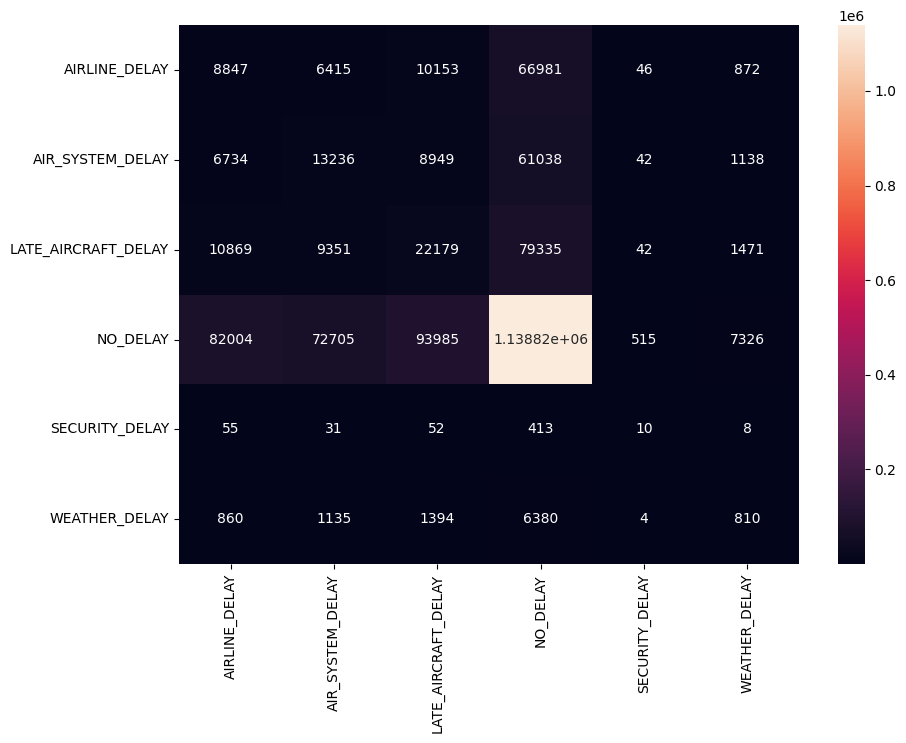

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,7))
sns.heatmap(cm , annot = True, fmt = 'g', xticklabels = clf.classes_, yticklabels = clf.classes_)

In [51]:
from sklearn.metrics import  classification_report
print(classification_report(y_test,y_pred))

                     precision    recall  f1-score   support

      AIRLINE_DELAY       0.08      0.09      0.09     93314
   AIR_SYSTEM_DELAY       0.13      0.15      0.14     91137
LATE_AIRCRAFT_DELAY       0.16      0.18      0.17    123247
           NO_DELAY       0.84      0.82      0.83   1395353
     SECURITY_DELAY       0.02      0.02      0.02       569
      WEATHER_DELAY       0.07      0.08      0.07     10583

           accuracy                           0.69   1714203
          macro avg       0.22      0.22      0.22   1714203
       weighted avg       0.71      0.69      0.70   1714203



In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn import svm

parameters = {'max_depth':[10,15],'max_features':["sqrt","log2"]}
tree = DecisionTreeClassifier()
grid_search = GridSearchCV(tree,parameters)
clf.fit(x_train,y_train)

DecisionTreeClassifier()

In [53]:
y_pred = clf.predict(x_test)
y_pred

array(['AIRLINE_DELAY', 'NO_DELAY', 'AIRLINE_DELAY', ..., 'NO_DELAY',
       'NO_DELAY', 'NO_DELAY'], shape=(1714203,), dtype=object)

In [54]:
print(classification_report(y_test,y_pred))

                     precision    recall  f1-score   support

      AIRLINE_DELAY       0.08      0.09      0.09     93314
   AIR_SYSTEM_DELAY       0.13      0.14      0.14     91137
LATE_AIRCRAFT_DELAY       0.16      0.18      0.17    123247
           NO_DELAY       0.84      0.82      0.83   1395353
     SECURITY_DELAY       0.02      0.02      0.02       569
      WEATHER_DELAY       0.07      0.08      0.07     10583

           accuracy                           0.69   1714203
          macro avg       0.22      0.22      0.22   1714203
       weighted avg       0.71      0.69      0.70   1714203



In [5]:
#cross validation
from sklearn.model_selection import cross_val_score

In [6]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=0)
cross_val_score(clf,x_flights,y_flights,cv=10)

NameError: name 'x_flights' is not defined

In [4]:
clf = RandomForestClassifier(n_estimators=50,max_depth=5,random_state=0)
cross_val_score(clf,x_flights,y_flights,cv=10)

NameError: name 'cross_val_score' is not defined

In [2]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=200,random_state=0)
cross_val_score(clf,x_flights,y_flights,cv=10)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\royal\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\royal\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\royal\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\royal\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\royal\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\royal\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

AttributeError: _ARRAY_API not found

NameError: name 'cross_val_score' is not defined